In [216]:
from helpers import *

import os
import re
import numpy as np
import matplotlib. pyplot as plt
from scipy.spatial.distance import directed_hausdorff

In [217]:
nubmer_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
n_runs= [10]

In [218]:
def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    # points = points[np.lexsort((points[:, 1], points[:, 0]))]
    n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points

In [219]:
def KS_Test(data, algo):
    
    # Perform K-S test
    ks_statistic, p_value = stats.kstest(data, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)
    
    print("********START********")
    # Display the results
    print("******KS-Test for {}".format(algo),"*********")
    print(f"K-S Statistic: {ks_statistic}")
    print(f"P-Value: {p_value}")

    # Decision based on the p-value
    alpha = 0.05
    if p_value > alpha:
        print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
    else:
        print("Reject the null hypothesis: The sample does not follow the uniform distribution.")
    
    print("********END********")

# GSM

In [220]:
main_path = "../GSM/solns_runs/Ex8/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]


## Number of starting points vs. PDP and HD

In [221]:
# Folders
# folders= {"n_runs_5":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_10":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_15":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_20":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list]}

folders= ["../GSM/solns_runs/Ex8/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../GSM/solns_runs/Ex8/N_100/',
 '../GSM/solns_runs/Ex8/N_200/',
 '../GSM/solns_runs/Ex8/N_300/',
 '../GSM/solns_runs/Ex8/N_400/',
 '../GSM/solns_runs/Ex8/N_500/',
 '../GSM/solns_runs/Ex8/N_600/',
 '../GSM/solns_runs/Ex8/N_700/',
 '../GSM/solns_runs/Ex8/N_800/',
 '../GSM/solns_runs/Ex8/N_900/',
 '../GSM/solns_runs/Ex8/N_1000/',
 '../GSM/solns_runs/Ex8/N_1100/',
 '../GSM/solns_runs/Ex8/N_1200/',
 '../GSM/solns_runs/Ex8/N_1300/',
 '../GSM/solns_runs/Ex8/N_1400/',
 '../GSM/solns_runs/Ex8/N_1500/']

In [222]:
# folders['n_runs_5']

In [223]:
import os

def list_txt_files_in_directory(directory_path):
#     try:
#         # List all files and directories in the specified path
    files_and_directories = os.listdir(directory_path)
#     print(directory_path)
    # Filter and print only .txt files
    txt_files = [file for file in files_and_directories if file.endswith('.txt')]
    txt_files = [file for file in txt_files if '.txt' in file]
    txt_files.sort()
    txt_files= [directory_path+"/"+file for file in txt_files]
        
    return txt_files

In [224]:

n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        point1 = (0, 1)
        point2 = (2/3, 2/3)

        # Number of points you want to generate

        # Generate points along the line segment
        points0 = [(point1[0] + t * (point2[0] - point1[0]), point1[1] + t * (point2[1] - point1[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3))]
        # points0= np.array(points0)


        # Define the three points
        point1 = (0, 1)
        point2 = (2/3, 2/3)
        point3 = (1, 0)

        # Number of points you want to generate on each segment


        # Generate points along the first segment
        points1 = [(point1[0] + t * (point2[0] - point1[0]), point1[1] + t * (point2[1] - point1[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3))]

        # Generate points along the second segment
        points2 = [(point2[0] + t * (point3[0] - point2[0]), point2[1] + t * (point3[1] - point2[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3)+1)]

        # Combine the points from both segments
        points = points0+points1 + points2
        points= np.array(points)

        

        print(len(distinct_points),len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../GSM/solns_runs/Ex8/plot_ex8.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

562 1000
1136 2000
1645 3000
2239 4000
2810 5000
3363 6000
3882 7000
4491 8000
5052 9000
5554 10000
6162 11000
6661 12000
7197 13000
7802 14000
8348 15000


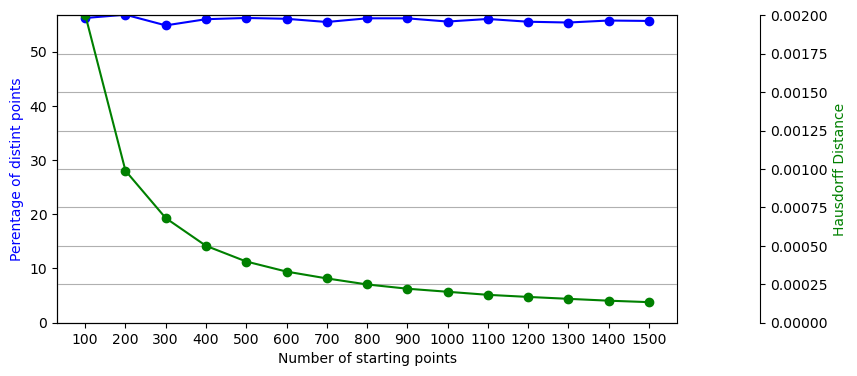

In [225]:
pdpgsm, hdgsm= get_values(folders)

In [226]:
for (p,h) in zip(pdpgsm, hdgsm):
    print(p, " * ", h)

56.2  *  0.00200335977272204
56.8  *  0.0009884961431316272
54.833333333333336  *  0.0006806181832186296
55.974999999999994  *  0.0005002146644787291
56.2  *  0.0003981783595620248
56.05  *  0.00033261989010053894
55.45714285714286  *  0.00028820488983376084
56.137499999999996  *  0.00024894206968311994
56.13333333333333  *  0.00022130628889619632
55.54  *  0.0002013292646971413
56.01818181818182  *  0.00018145650483671768
55.50833333333334  *  0.0001678423813745894
55.36153846153846  *  0.0001554118949811384
55.72857142857143  *  0.00014333640111435233
55.653333333333336  *  0.0001339291377303538


In [227]:
max(pdpgsm), min(hdgsm)

(56.8, 0.0001339291377303538)

In [228]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
            num, distinct_points = count_repeated_points(solns)
            distinct_points= np.array(distinct_points)
            res.extend(distinct_points.tolist())
#             break
            
        all_solns.append(res)
        
    
#     print(np.array(all_solns[0])[:,0])
    
    for i in range(len(all_solns)):
        print("Plot for {} points".format(nubmer_points_list[i]))
        plt.scatter(np.array(all_solns[i])[:,0], np.array(all_solns[i])[:,1], c= 'black')
        plt.xlim([0,1.0])
        plt.ylim([0,1.0])
        plt.grid(True)
        plt.show()

In [229]:
## Plot solution sets
#plot_solns(folders)

In [230]:
np.argmax(pdpgsm)

1

## Histograms

In [231]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpgsm)]
print(n_points)
# Best
directory_path = "../GSM/solns_runs/Ex8/N_{}".format(n_points)
all_solnsgsm= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnsgsm.extend(solns.tolist())

all_solnsgsm= np.array(all_solnsgsm)

num, all_solnsgsm = count_repeated_points(all_solnsgsm)
all_solnsgsm= np.array(all_solnsgsm)
print(len(all_solnsgsm))

200
1136


In [232]:
all_solnsgsm

array([[0.66478868, 0.66760566],
       [0.35793022, 0.82103489],
       [0.99688445, 0.00623109],
       ...,
       [0.76463712, 0.47072577],
       [0.8845104 , 0.2309792 ],
       [0.8516729 , 0.2966542 ]])

In [233]:
len(all_solnsgsm)
# print(all_solnsgsm)

1136

In [234]:
def partition_interval(a, b, n):
#     n= n-1
    interval_length = b - a
    partition_width = interval_length / n
    partition_points = [a + i * partition_width for i in range(n + 1)]
    return partition_points

def count_values_in_bins(values, bins):
    # Initialize a dictionary to store the counts for each bin
    bin_counts = {bin_index: 0 for bin_index in range(len(bins) - 1)}

    # Iterate over each value
    for value in values:
        # Find the bin that the value falls into
        bin_index = 0
        while bin_index < len(bins) - 1 and not (bins[bin_index] <= value < bins[bin_index + 1]):
            bin_index += 1

        # Increment the count for the corresponding bin.
        if bin_index < len(bins) - 1:
            bin_counts[bin_index] += 1

    return bin_counts

## x:
bins_list= [5, 10, 15, 20]
solns= all_solnsgsm.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xgsm= x.copy()
ygsm= y.copy()

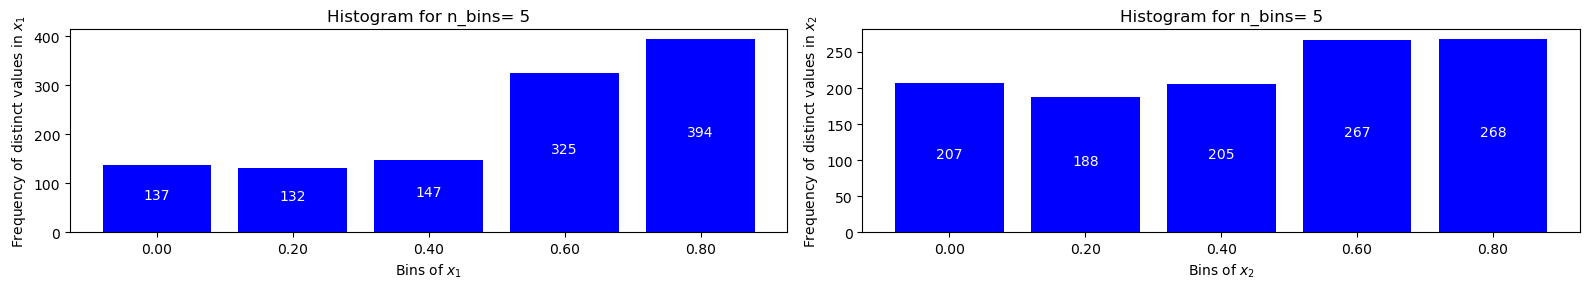

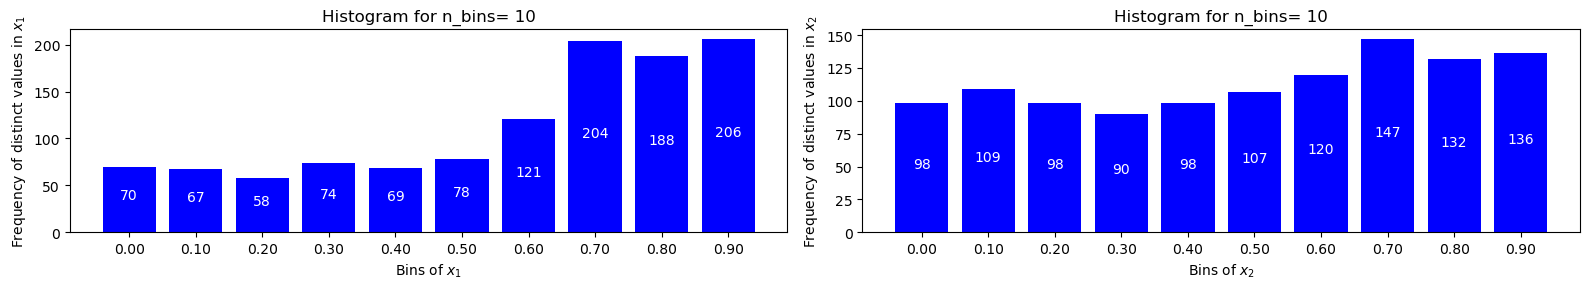

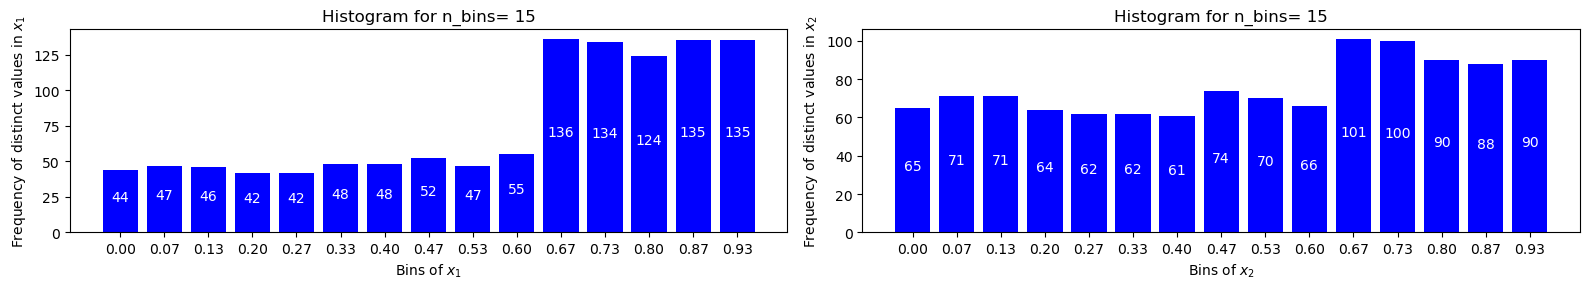

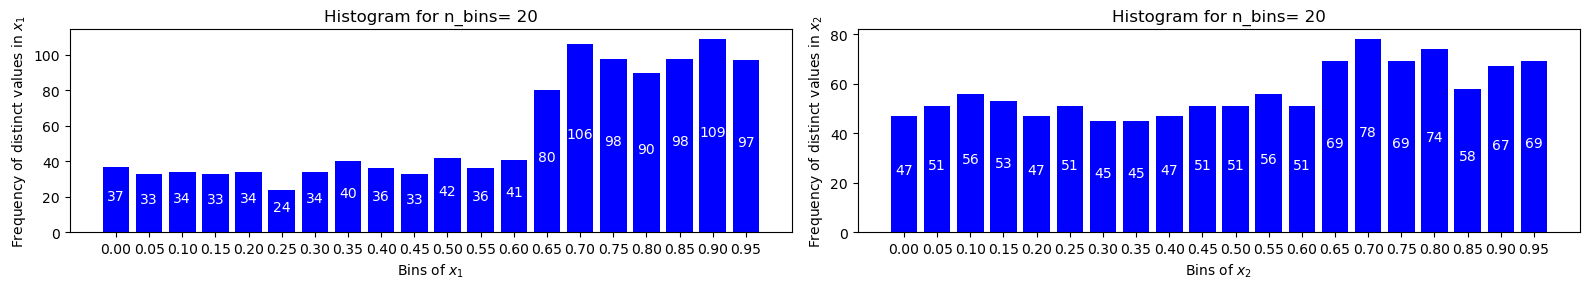

In [235]:
x_hist_gsm= []
y_hist_gsm= []
y_part_gsm= []
x_part_gsm= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_gsm.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_gsm.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_gsm.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_gsm.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../GSM/solns_runs/Ex8/'+'ex8_gsm_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF

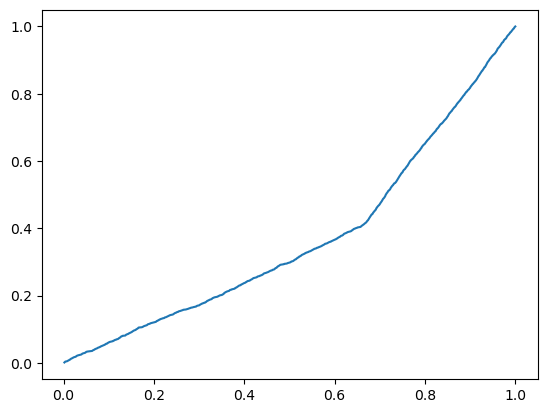

In [236]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib import pyplot
from numpy.random import normal
from numpy import hstack
from statsmodels.distributions.empirical_distribution import ECDF
# fit a cdf
ecdf = ECDF(xgsm)
plt.plot(ecdf.x, ecdf.y)
plt.show()


def get_cdf_of_uniform(x, a, b):
    if x<a:
        return 0
    elif a<=x<b:
        return (x-a)/(b-a)
    elif x>b:
        return 1

## KS-Test

In [237]:
import numpy as np
from scipy import stats

# Example data (replace with your actual data)
np.random.seed(0)
data = np.random.uniform(0,1, size=100)

# Perform KS test against a normal distribution (null hypothesis)
ks_statistic, p_value = stats.kstest(data, 'norm')

# Print the results
print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis that the data is normally distributed.")
else:
    print("Cannot reject the null hypothesis that the data is normally distributed.")


KS Statistic: 0.5018732170965315
P-value: 7.902176095057781e-24
Reject the null hypothesis that the data is normally distributed.


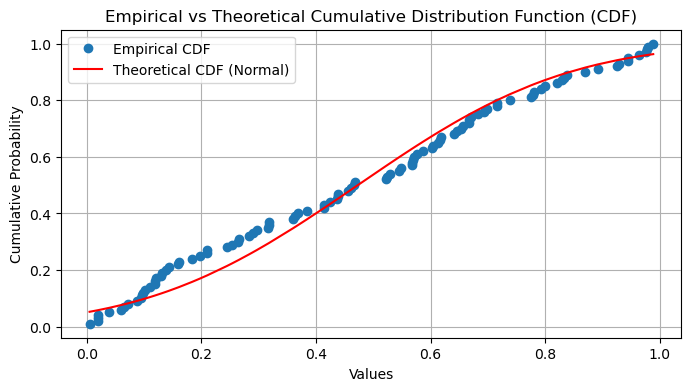

In [238]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Example data (replace with your actual data)
np.random.seed(0)
# data = np.random.normal(loc=0, scale=1, size=100)

# Sort the data
sorted_data = np.sort(data)

# Calculate the empirical CDF
n = sorted_data.size
y_empirical = np.arange(1, n+1) / n

# Calculate the theoretical CDF (normal distribution)
mean, std = np.mean(data), np.std(data)
y_theoretical = stats.norm.cdf(sorted_data, loc=mean, scale=std)

# Plotting the empirical and theoretical CDFs
plt.figure(figsize=(8, 4))
plt.plot(sorted_data, y_empirical, label='Empirical CDF', marker='o', linestyle='none')
plt.plot(sorted_data, y_theoretical, label='Theoretical CDF (Normal)', color='red')
plt.xlabel('Values')
plt.ylabel('Cumulative Probability')
plt.title('Empirical vs Theoretical Cumulative Distribution Function (CDF)')
plt.legend()
plt.grid(True)
plt.show()


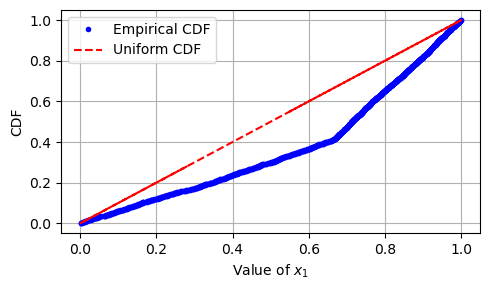

K-S Statistic: 0.254177844196014
P-Value: 3.4866773497232538e-65
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [239]:
# KS Test on x: 
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
#uniform_samples= np.hstack((uniform_samples,5.0))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xgsm)
ecdf_gsm_x = ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_x.x, ecdf_gsm_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([5.0],[1], 'r--')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../GSM/solns_runs/Ex8/ks_ex8_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xgsm, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

In [240]:
ecdf_gsm_x.y

array([0.00000000e+00, 8.80281690e-04, 1.76056338e-03, ...,
       9.98239437e-01, 9.99119718e-01, 1.00000000e+00])

In [241]:
ecdf_gsm_x.x

array([      -inf, 0.00171542, 0.00225161, ..., 0.99849093, 0.9992988 ,
       0.99985055])

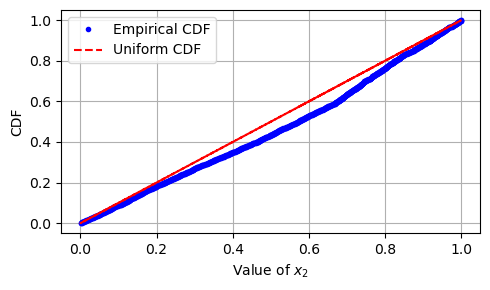

K-S Statistic: 0.08071219388152673
P-Value: 6.944042718388122e-07
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [242]:
# KS Test on y: 
# Number of samples
a,b= 0.0, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(x)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ygsm)
ecdf_gsm_y = ECDF(ygsm) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_y.x, ecdf_gsm_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../GSM/solns_runs/Ex8/ks_ex8_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ygsm, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


# PVI

In [243]:
nubmer_points_list= [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]

In [244]:
# nubmer_points_list= nubmer_points_list[:-1]
# nubmer_points_list

In [245]:
from math import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar


# Define objective functions for each player
def player1_objective(x):
    return -x[0]

def player2_objective(x):
    return -x[1]


# Define constraints for each player
def constraint_function1(x):
    return (0.5*x[0]+x[1])-1

def constraint_function2(x):
    return (x[0]+0.5*x[1])-1

# def grad_cons1(x):
#   return np.array([-3.25, -1.25, -4.125])

def constraint_function(x):
  return np.array([constraint_function1(x),constraint_function2(x)])

In [246]:
# New

## Load data

import json

# with open('../Scripts/PVI/Ex3PVI.json') as f:
#     data= json.load(f)

with open('../Scripts/PVI/Ex7PVIT.json') as f:
    dataT= json.load(f)

T_list= [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
data_dict= dict.fromkeys(range(1, len(T_list)+1), 0)

data_dict



for T in T_list:
    data_all= []

    for i in range(len(nubmer_points_list)):
        res_= []

        if len(dataT[str(T)][i])== 0:
            # print(dataT[str(1)][i])
            data_all.append([dataT[str(T)][i]])
            # res_.append([dataT[str(1)][i]])
        else:
            
            for t in range(len(dataT[str(T)][i])):
                #print(data[str(i)][t])
                #if np.abs(constraint_function(dataT[str(T)][i][t]))<= 1e-6:
                res_.append(dataT[str(T)][i][t])
            data_all.append(res_)
    data_dict[T]= data_all


res_all= []

for i in range(len(nubmer_points_list)):
    res= []
    for T in T_list:
        res.extend(data_dict[T][i])

    res_all.append(res)

data_all= res_all

In [247]:
data_all

[[[0.6666666656325033, 0.6666666671837485],
  [0.6666666663436462, 0.6666666668281768],
  [0.666666665507685, 0.6666666672461574],
  [0.6666666666666667, 0.6666666666666666],
  [0.6666666666666666, 0.6666666666666667],
  [0.6666666666675556, 0.6666666666648888],
  [0.6666666666666666, 0.6666666666666667],
  [0.6666666651861671, 0.6666666674069166],
  [0.666666665504725, 0.6666666672476375],
  [0.6666666672391395, 0.6666666655217213],
  [0.6666666666666666, 0.6666666666666667],
  [0.6666666656745673, 0.6666666671627164],
  [0.6666666666666666, 0.6666666666666666],
  [0.6666666666666666, 0.6666666666666667],
  [0.6666666659006452, 0.6666666670496774],
  [0.6666666672973415, 0.6666666654053169],
  [0.6666666667537489, 0.6666666664925022],
  [0.6666666651928423, 0.6666666674035788],
  [0.6666666666666667, 0.6666666666666666],
  [0.6666666666512465, 0.6666666666743768],
  [0.6666666666666667, 0.6666666666666666],
  [0.6666666684063951, 0.66666666318721],
  [0.6666666666666666, 0.66666666666

In [248]:
data= []
dist_= []
avg_hd= []

for (idx, pt) in enumerate(nubmer_points_list):
    dt= []
    

    num_points= nubmer_points_list[idx]

    num, distinct_points = count_repeated_points(np.array(data_all[idx]))
    distinct_points= np.array(distinct_points)  

    point1 = (0, 1)
    point2 = (2/3, 2/3)

    # Number of points you want to generate

    # Generate points along the line segment
    points0 = [(point1[0] + t * (point2[0] - point1[0]), point1[1] + t * (point2[1] - point1[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3))]
    # points0= np.array(points0)


    # Define the three points
    point1 = (0, 1)
    point2 = (2/3, 2/3)
    point3 = (1, 0)

    # Number of points you want to generate on each segment


    # Generate points along the first segment
    points1 = [(point1[0] + t * (point2[0] - point1[0]), point1[1] + t * (point2[1] - point1[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3))]

    # Generate points along the second segment
    points2 = [(point2[0] + t * (point3[0] - point2[0]), point2[1] + t * (point3[1] - point2[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3)+1)]

    # Combine the points from both segments
    points = points0+points1 + points2
    points= np.array(points)
    
    
    hausdorff_distance = directed_hausdorff(np.array(data_all[idx]), points)[0]
    dist_.append((len(distinct_points)/(len(data_all[idx])))*100)
    avg_hd.append(hausdorff_distance)

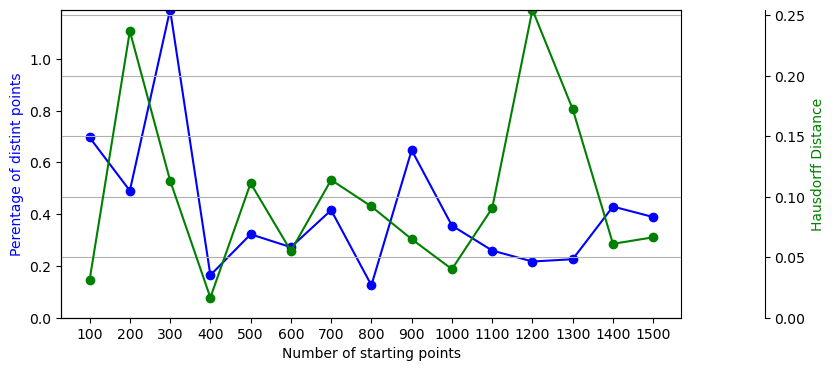

In [249]:
fig, ax1 = plt.subplots(figsize=(8, 4))

# Create second axis with different scale
ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
ax1.set_ylim([0.0, np.max(dist_)])
ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


# Create third axis with different scale
ax2 = ax1.twinx()
ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
ax2.plot(nubmer_points_list, avg_hd, 'go-')
ax2.set_ylabel('Hausdorff Distance', color='g')
ax2.set_ylim([0.0, np.max(avg_hd)])

xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
ax1.set_xticks(xticks)
ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


plt.savefig('../PVI/solns_runs/Ex8/plot_ex8.png')
plt.grid(True)
plt.show()

In [250]:
pdppvi, hdgpvi= dist_.copy(),avg_hd.copy()

In [251]:
pdppvi

[0.6968641114982579,
 0.4909983633387889,
 1.1904761904761905,
 0.16433853738701726,
 0.3225806451612903,
 0.27262813522355506,
 0.41570438799076215,
 0.12547051442910914,
 0.647715005397625,
 0.356102298478472,
 0.259665320253895,
 0.21727322107550243,
 0.22613065326633164,
 0.42969682501790407,
 0.38910505836575876]

In [252]:
hdgpvi

[0.031088861618794966,
 0.23697772353123525,
 0.11339654576931504,
 0.01660001872446677,
 0.11121180854719755,
 0.055210114818370036,
 0.11395343083683117,
 0.0919959119689182,
 0.06498492725705321,
 0.04018956768934811,
 0.09057081426188682,
 0.2546769767362054,
 0.17246520314237354,
 0.06110098027474912,
 0.06650543064469527]

In [253]:
for (p,h) in zip(pdppvi,hdgpvi):
    print(p, " *** ", h)

0.6968641114982579  ***  0.031088861618794966
0.4909983633387889  ***  0.23697772353123525
1.1904761904761905  ***  0.11339654576931504
0.16433853738701726  ***  0.01660001872446677
0.3225806451612903  ***  0.11121180854719755
0.27262813522355506  ***  0.055210114818370036
0.41570438799076215  ***  0.11395343083683117
0.12547051442910914  ***  0.0919959119689182
0.647715005397625  ***  0.06498492725705321
0.356102298478472  ***  0.04018956768934811
0.259665320253895  ***  0.09057081426188682
0.21727322107550243  ***  0.2546769767362054
0.22613065326633164  ***  0.17246520314237354
0.42969682501790407  ***  0.06110098027474912
0.38910505836575876  ***  0.06650543064469527


In [254]:
max(pdppvi), min(hdgpvi)

(1.1904761904761905, 0.01660001872446677)

In [255]:
pdppvi_all, hdgpvi_all= dist_.copy(),avg_hd.copy()

In [256]:
avg_hd

[0.031088861618794966,
 0.23697772353123525,
 0.11339654576931504,
 0.01660001872446677,
 0.11121180854719755,
 0.055210114818370036,
 0.11395343083683117,
 0.0919959119689182,
 0.06498492725705321,
 0.04018956768934811,
 0.09057081426188682,
 0.2546769767362054,
 0.17246520314237354,
 0.06110098027474912,
 0.06650543064469527]

In [257]:
nubmer_points_list[9:]

[1000, 1100, 1200, 1300, 1400, 1500]

In [258]:
pdppvi_all

[0.6968641114982579,
 0.4909983633387889,
 1.1904761904761905,
 0.16433853738701726,
 0.3225806451612903,
 0.27262813522355506,
 0.41570438799076215,
 0.12547051442910914,
 0.647715005397625,
 0.356102298478472,
 0.259665320253895,
 0.21727322107550243,
 0.22613065326633164,
 0.42969682501790407,
 0.38910505836575876]

In [259]:
hdgpvi_all

[0.031088861618794966,
 0.23697772353123525,
 0.11339654576931504,
 0.01660001872446677,
 0.11121180854719755,
 0.055210114818370036,
 0.11395343083683117,
 0.0919959119689182,
 0.06498492725705321,
 0.04018956768934811,
 0.09057081426188682,
 0.2546769767362054,
 0.17246520314237354,
 0.06110098027474912,
 0.06650543064469527]

In [260]:
npts= 300
point1 = (0, 1)
point2 = (2/3, 2/3)

# Number of points you want to generate

# Generate points along the line segment
points0 = [(point1[0] + t * (point2[0] - point1[0]), point1[1] + t * (point2[1] - point1[1])) for t in np.linspace(0, 1, int(npts/3))]
# points0= np.array(points0)


# Define the three points
point1 = (0, 1)
point2 = (2/3, 2/3)
point3 = (1, 0)

# Number of points you want to generate on each segment


# Generate points along the first segment
points1 = [(point1[0] + t * (point2[0] - point1[0]), point1[1] + t * (point2[1] - point1[1])) for t in np.linspace(0, 1, int(npts/3))]

# Generate points along the second segment
points2 = [(point2[0] + t * (point3[0] - point2[0]), point2[1] + t * (point3[1] - point2[1])) for t in np.linspace(0, 1, int(npts/3)+1)]

# Combine the points from both segments
points = points0+points1 + points2
points= np.array(points)

In [261]:
# max(dist_), min(avg_hd)
# np.array(data[9]), len(np.array(data[9]))

In [262]:
# # Best npoint
# sol= np.array(data[0])
# print(sol)

## Histogram

In [263]:
data_all

[[[0.6666666656325033, 0.6666666671837485],
  [0.6666666663436462, 0.6666666668281768],
  [0.666666665507685, 0.6666666672461574],
  [0.6666666666666667, 0.6666666666666666],
  [0.6666666666666666, 0.6666666666666667],
  [0.6666666666675556, 0.6666666666648888],
  [0.6666666666666666, 0.6666666666666667],
  [0.6666666651861671, 0.6666666674069166],
  [0.666666665504725, 0.6666666672476375],
  [0.6666666672391395, 0.6666666655217213],
  [0.6666666666666666, 0.6666666666666667],
  [0.6666666656745673, 0.6666666671627164],
  [0.6666666666666666, 0.6666666666666666],
  [0.6666666666666666, 0.6666666666666667],
  [0.6666666659006452, 0.6666666670496774],
  [0.6666666672973415, 0.6666666654053169],
  [0.6666666667537489, 0.6666666664925022],
  [0.6666666651928423, 0.6666666674035788],
  [0.6666666666666667, 0.6666666666666666],
  [0.6666666666512465, 0.6666666666743768],
  [0.6666666666666667, 0.6666666666666666],
  [0.6666666684063951, 0.66666666318721],
  [0.6666666666666666, 0.66666666666

In [264]:
# PVI
data= data_all
solnspvi= np.array(data[np.argmax(pdppvi)]) #np.array(data[14])

num, distinct_points = count_repeated_points(solnspvi)
solnspvi= np.array(distinct_points)
solnspvi

array([[0.66666667, 0.66666667],
       [0.79857717, 0.40283847],
       [0.61955822, 0.69021693],
       [0.76094266, 0.47810675],
       [0.76550491, 0.46898233],
       [0.80555657, 0.38887983],
       [0.71737596, 0.56524012],
       [0.67858543, 0.64282122],
       [0.75720892, 0.48557417],
       [0.681077  , 0.63783807]])

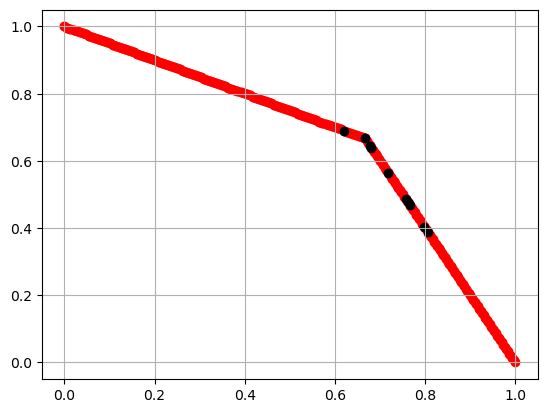

In [265]:
plt.scatter(points[:,0], points[:,1], c= 'red')
plt.scatter(solnspvi[:,0], solnspvi[:,1], c= 'black')

#plt.xlim([0,1.0])
#plt.ylim([0,1.0])
plt.grid(True)
plt.show()

In [266]:
## x:
bins_list= [5, 10, 15, 20]
solns= solnspvi.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xpvi= x.copy()
ypvi= y.copy()

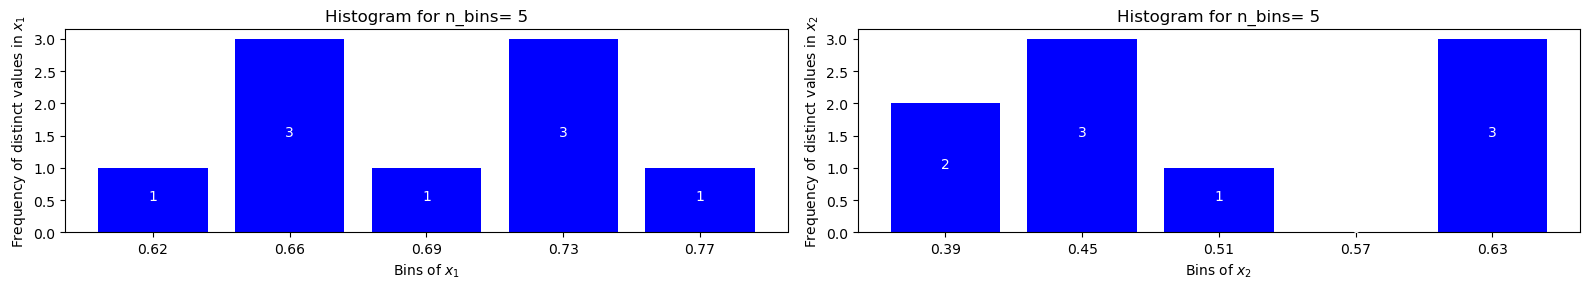

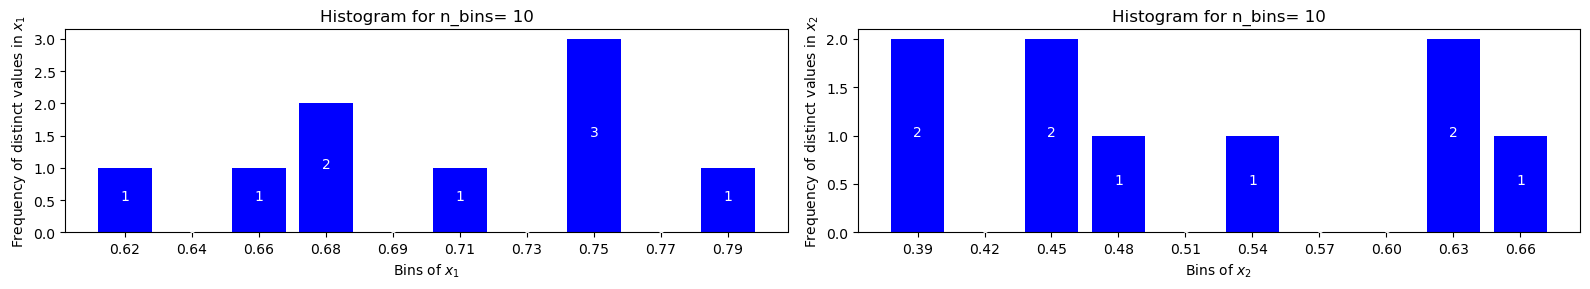

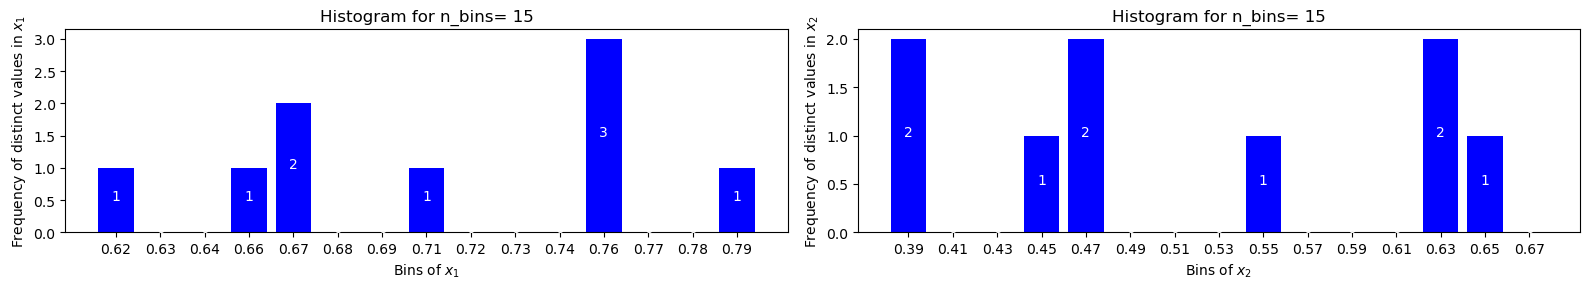

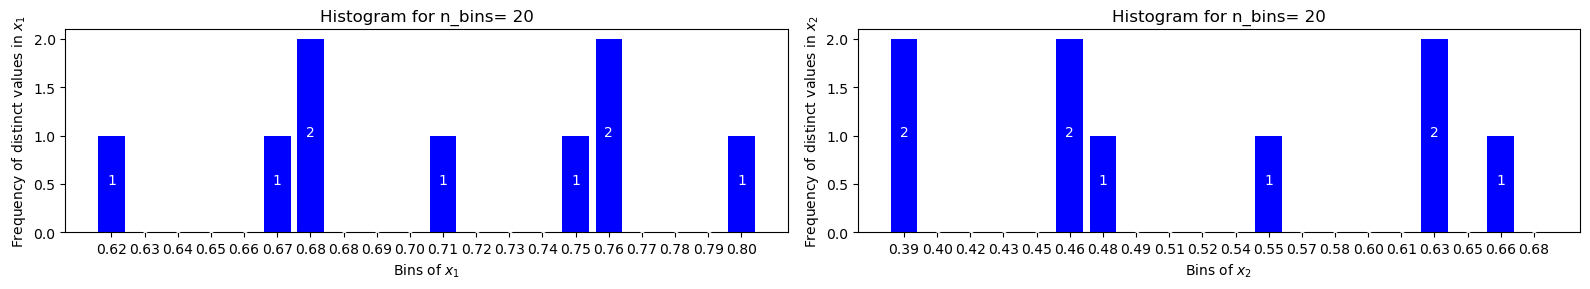

In [267]:
x_hist_pvi= []
y_hist_pvi= []
y_part_pvi= []
x_part_pvi= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_pvi.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_pvi.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_pvi.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_pvi.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../PVI/solns_runs/Ex8/'+'ex8_pvi_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF and KS-Test

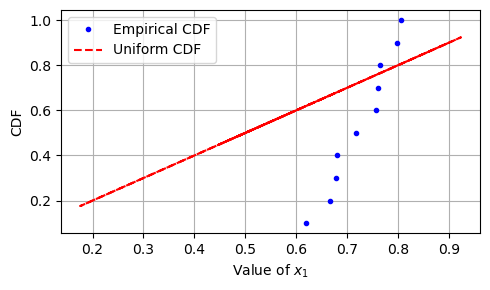

K-S Statistic: 0.6195582179988754
P-Value: 0.0003140818662709609
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [268]:
# KS Test on x: 
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xpvi))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xpvi)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xpvi)
ecdf_pvi_x = ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_pvi_x.x, ecdf_pvi_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('../PVI/solns_runs/Ex4/ks_ex4_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xpvi, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

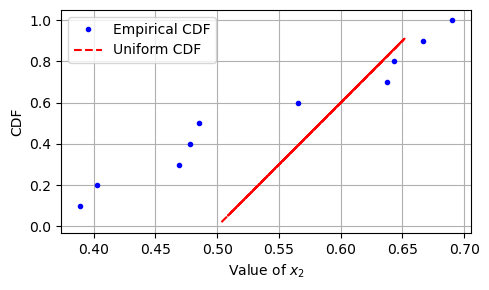

K-S Statistic: 0.3888798284123775
P-Value: 0.07153989359336155
Fail to reject the null hypothesis: The sample follows the uniform distribution.


In [269]:
# KS Test on y: 
# Number of samples
a,b=  1/2, 2/3
uniform_samples = np.random.uniform(low=a, high=b, size=len(ypvi))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ypvi)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ypvi)
ecdf_gsm_y = ECDF(ypvi) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_y.x, ecdf_gsm_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('../PVI/solns_runs/Ex4/ks_ex4_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ypvi, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


### Number of starting points vs. PDP and HD

In [270]:
nubmer_points_list= [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]

# BFGS

In [271]:
def list_subfolders(folder_path):
    subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
    sorted_subfolders = sorted(subfolders, key=lambda x: int(x.split("_")[-1]))
    return sorted_subfolders


def list_txt_files(folder_path):
    txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
#     txt_files = sorted(txt_files, key=lambda x: int(x.split("_")[2]))
    return txt_files

### Number of starting points vs. PDP and HD

In [272]:
main_path = "../Merit/solns_runs/Ex8/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../Merit/solns_runs/Ex8/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../Merit/solns_runs/Ex8/N_100/',
 '../Merit/solns_runs/Ex8/N_200/',
 '../Merit/solns_runs/Ex8/N_300/',
 '../Merit/solns_runs/Ex8/N_400/',
 '../Merit/solns_runs/Ex8/N_500/',
 '../Merit/solns_runs/Ex8/N_600/',
 '../Merit/solns_runs/Ex8/N_700/',
 '../Merit/solns_runs/Ex8/N_800/',
 '../Merit/solns_runs/Ex8/N_900/',
 '../Merit/solns_runs/Ex8/N_1000/',
 '../Merit/solns_runs/Ex8/N_1100/',
 '../Merit/solns_runs/Ex8/N_1200/',
 '../Merit/solns_runs/Ex8/N_1300/',
 '../Merit/solns_runs/Ex8/N_1400/',
 '../Merit/solns_runs/Ex8/N_1500/']

In [273]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        point1 = (0, 1)
        point2 = (2/3, 2/3)

        # Number of points you want to generate

        # Generate points along the line segment
        points0 = [(point1[0] + t * (point2[0] - point1[0]), point1[1] + t * (point2[1] - point1[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3))]
        # points0= np.array(points0)


        # Define the three points
        point1 = (0, 1)
        point2 = (2/3, 2/3)
        point3 = (1, 0)

        # Number of points you want to generate on each segment


        # Generate points along the first segment
        points1 = [(point1[0] + t * (point2[0] - point1[0]), point1[1] + t * (point2[1] - point1[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3))]

        # Generate points along the second segment
        points2 = [(point2[0] + t * (point3[0] - point2[0]), point2[1] + t * (point3[1] - point2[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3)+1)]

        # Combine the points from both segments
        points = points0+points1 + points2
        points= np.array(points)

        

        print(len(distinct_points),len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../Merit/solns_runs/Ex8/plot_ex8.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

155 1000
307 2000
465 3000
623 4000
774 5000
902 6000
1071 7000
1257 8000
1402 9000
1574 10000
1707 11000
1873 12000
1886 13000
1967 14000
2142 15000


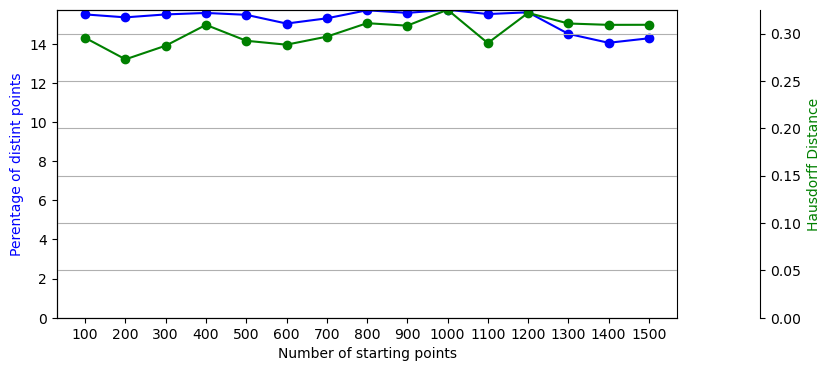

In [274]:
pdpbfgs, hdbfgs= get_values(folders)

In [275]:
for (p,h) in zip(pdpbfgs,hdbfgs):
    print(p, " * ", h)

15.5  *  0.2954339337467266
15.35  *  0.272762911525837
15.5  *  0.28718116681743616
15.575  *  0.30913962719618326
15.479999999999999  *  0.2923596625245827
15.033333333333335  *  0.2882332479889164
15.299999999999999  *  0.2966971697821128
15.712499999999999  *  0.31092346241864927
15.577777777777776  *  0.3083030226490598
15.740000000000002  *  0.32512959439395744
15.518181818181818  *  0.2899296869199306
15.608333333333333  *  0.3217950732354377
14.507692307692308  *  0.31058641828554484
14.05  *  0.3091595231779315
14.280000000000001  *  0.3092265772523281


In [276]:
max(pdpbfgs), min(hdbfgs)

(15.740000000000002, 0.272762911525837)

In [277]:
# plot_solns(folders)

In [278]:
nubmer_points_list[np.argmax(pdpbfgs)]

1000

### Histograms

In [279]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpbfgs)]
# Best
directory_path = "../Merit/solns_runs/Ex8/N_{}".format(n_points)
all_solnsbfgs= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnsbfgs.extend(solns.tolist())

all_solnsbfgs= np.array(all_solnsbfgs)

num, all_solnsbfgs = count_repeated_points(all_solnsbfgs)
all_solnsbfgs= np.array(all_solnsbfgs)

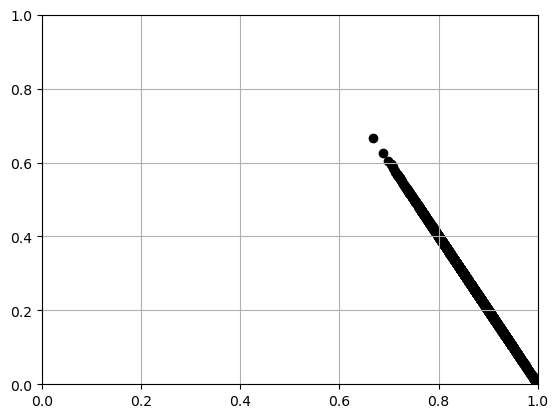

In [280]:
plt.scatter(all_solnsbfgs[:,0], all_solnsbfgs[:,1], c= 'black')
plt.xlim([0,1.0])
plt.ylim([0,1.0])
plt.grid(True)
plt.show()

In [281]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnsbfgs.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xbfgs= x.copy()
ybfgs= y.copy()

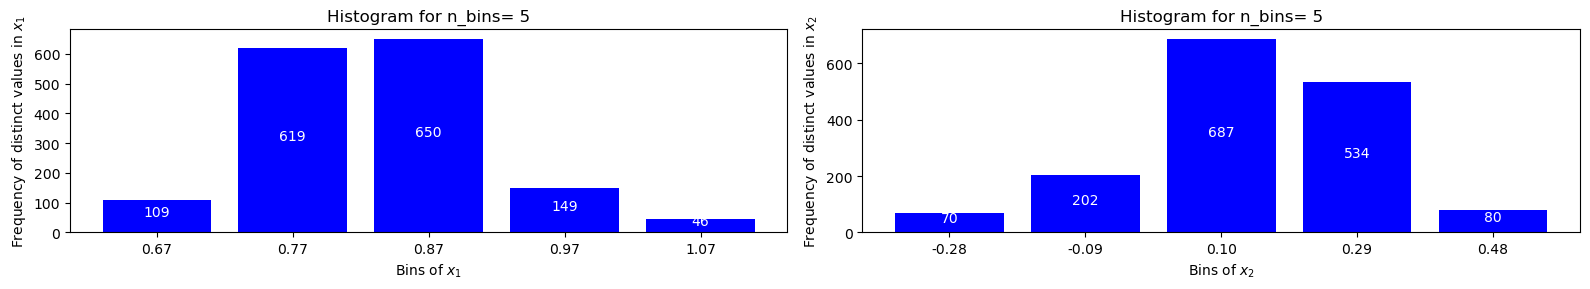

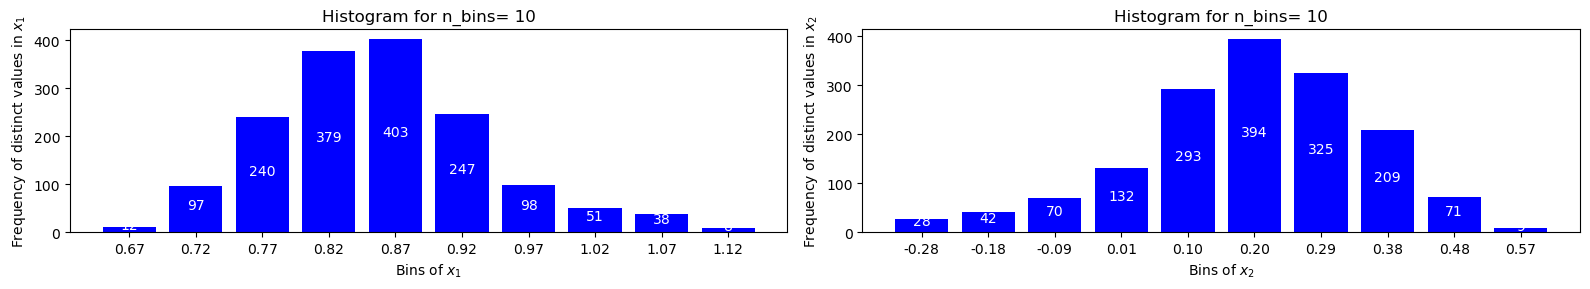

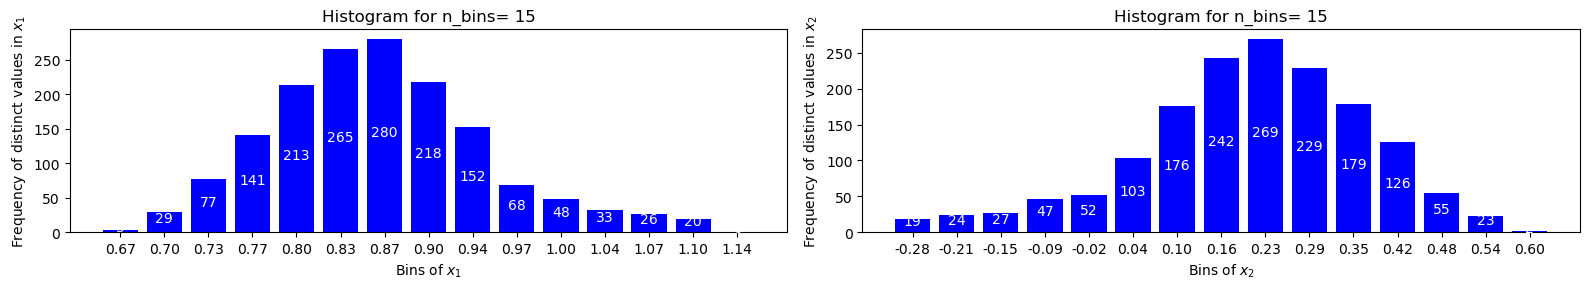

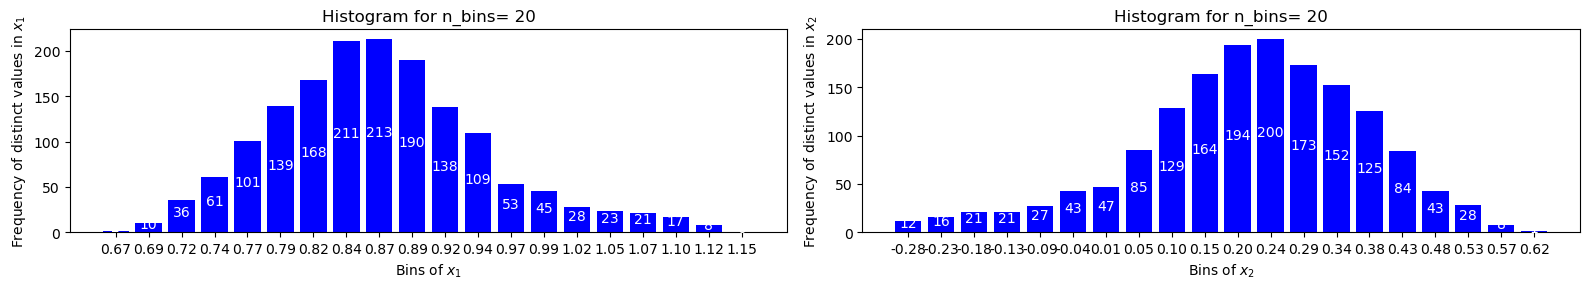

In [282]:
x_hist_bfgs= []
y_hist_bfgs= []
y_part_bfgs= []
x_part_bfgs= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_bfgs.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_bfgs.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_bfgs.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_bfgs.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../Merit/solns_runs/Ex8/'+'ex8_bfgs_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and KS-Test

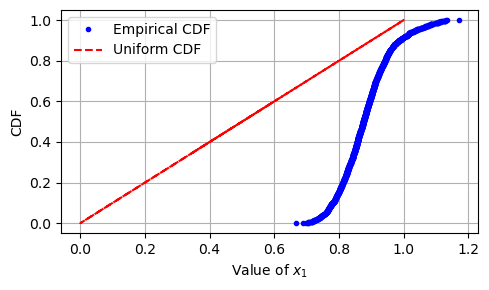

K-S Statistic: 0.7145661142369422
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [283]:
 # KS Test on x: 
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xbfgs)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xbfgs)
ecdf_bfgs_x = ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_x.x, ecdf_bfgs_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../Merit/solns_runs/Ex8/ks_ex8_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xbfgs, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

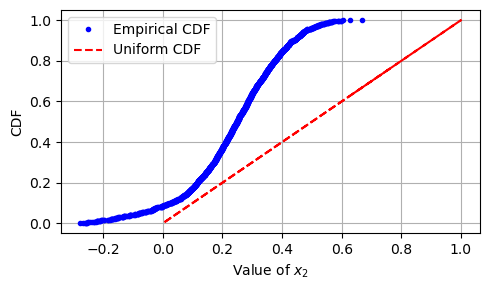

K-S Statistic: 0.47093628109693764
P-Value: 8.864e-321
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [284]:
# KS Test on y: 
# Number of samples
a,b= 0.0, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ybfgs)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ybfgs)
ecdf_bfgs_y = ECDF(ybfgs) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_y.x, ecdf_bfgs_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../Merit/solns_runs/Ex8/ks_ex8_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ybfgs, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# EIA

## Number of starting points vs. PDP and HD

In [285]:
main_path = "../EIA/solns_runs/Ex8/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../EIA/solns_runs/Ex8/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../EIA/solns_runs/Ex8/N_100/',
 '../EIA/solns_runs/Ex8/N_200/',
 '../EIA/solns_runs/Ex8/N_300/',
 '../EIA/solns_runs/Ex8/N_400/',
 '../EIA/solns_runs/Ex8/N_500/',
 '../EIA/solns_runs/Ex8/N_600/',
 '../EIA/solns_runs/Ex8/N_700/',
 '../EIA/solns_runs/Ex8/N_800/',
 '../EIA/solns_runs/Ex8/N_900/',
 '../EIA/solns_runs/Ex8/N_1000/',
 '../EIA/solns_runs/Ex8/N_1100/',
 '../EIA/solns_runs/Ex8/N_1200/',
 '../EIA/solns_runs/Ex8/N_1300/',
 '../EIA/solns_runs/Ex8/N_1400/',
 '../EIA/solns_runs/Ex8/N_1500/']

In [286]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        point1 = (0, 1)
        point2 = (2/3, 2/3)

        # Number of points you want to generate

        # Generate points along the line segment
        points0 = [(point1[0] + t * (point2[0] - point1[0]), point1[1] + t * (point2[1] - point1[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3))]
        # points0= np.array(points0)


        # Define the three points
        point1 = (0, 1)
        point2 = (2/3, 2/3)
        point3 = (1, 0)

        # Number of points you want to generate on each segment


        # Generate points along the first segment
        points1 = [(point1[0] + t * (point2[0] - point1[0]), point1[1] + t * (point2[1] - point1[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3))]

        # Generate points along the second segment
        points2 = [(point2[0] + t * (point3[0] - point2[0]), point2[1] + t * (point3[1] - point2[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3)+1)]

        # Combine the points from both segments
        points = points0+points1 + points2
        points= np.array(points)

        

        print(len(distinct_points))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../EIA/solns_runs/Ex8/plot_ex8.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

810
1583
2452
3281
4036
4900
5756
6553
7385
7988
8993
9692
10507
11405
12189


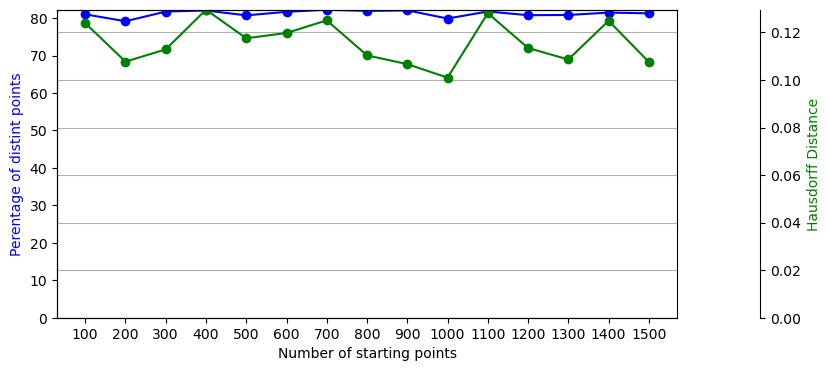

In [287]:
pdpeia, hdeia= get_values(folders)

In [288]:
for (p,h) in zip(pdpeia,hdeia):
    print(p, " * ", h)

81.0  *  0.12391003308932623
79.14999999999999  *  0.10771084193395078
81.73333333333333  *  0.11285508678766655
82.025  *  0.12954199573045808
80.72  *  0.11753957954292316
81.66666666666667  *  0.11975623622648034
82.22857142857143  *  0.12506284812219698
81.9125  *  0.11033239694684242
82.05555555555556  *  0.10665951609034026
79.88  *  0.10098375425786736
81.75454545454545  *  0.12807124439009723
80.76666666666667  *  0.11344094942619479
80.82307692307693  *  0.10861156002566993
81.46428571428571  *  0.12488355232390282
81.26  *  0.10756643982446472


In [289]:
max(pdpeia), min(hdeia)

(82.22857142857143, 0.10098375425786736)

In [290]:
#plot_solns(folders)

In [291]:
nubmer_points_list[np.argmax(pdpeia)]

700

### Histograms

In [292]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpeia)]
# Best
directory_path = "../EIA/solns_runs/Ex8/N_{}".format(n_points)
all_solnseia= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnseia.extend(solns.tolist())

all_solnseia= np.array(all_solnseia)


_,all_solnseia= count_repeated_points(all_solnseia)
all_solnseia= np.array(all_solnseia)

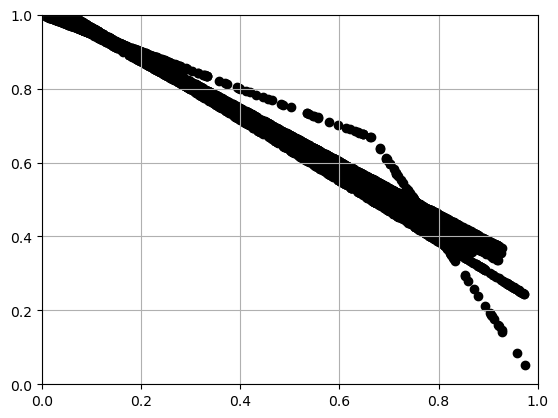

In [293]:
plt.scatter(all_solnseia[:,0], all_solnseia[:,1], c= 'black')
plt.xlim([0,1.0])
plt.ylim([0,1.0])
plt.grid(True)
plt.show()

In [294]:
bins_list= [5, 10, 15, 20]
solns= all_solnseia.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

# y

xeia= x.copy()
yeia= y.copy()

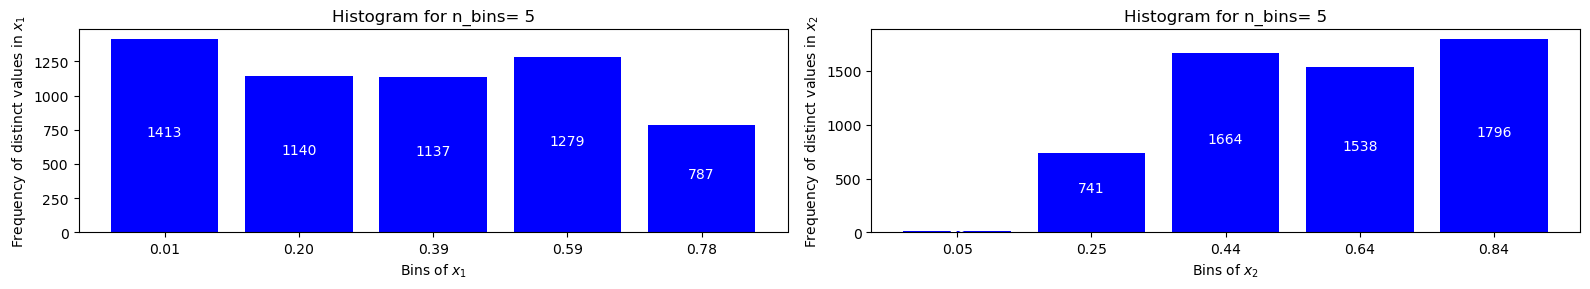

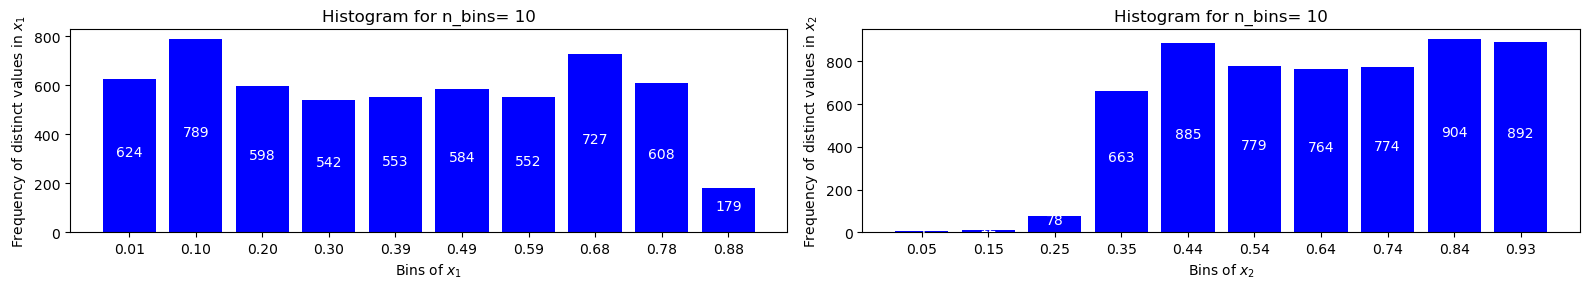

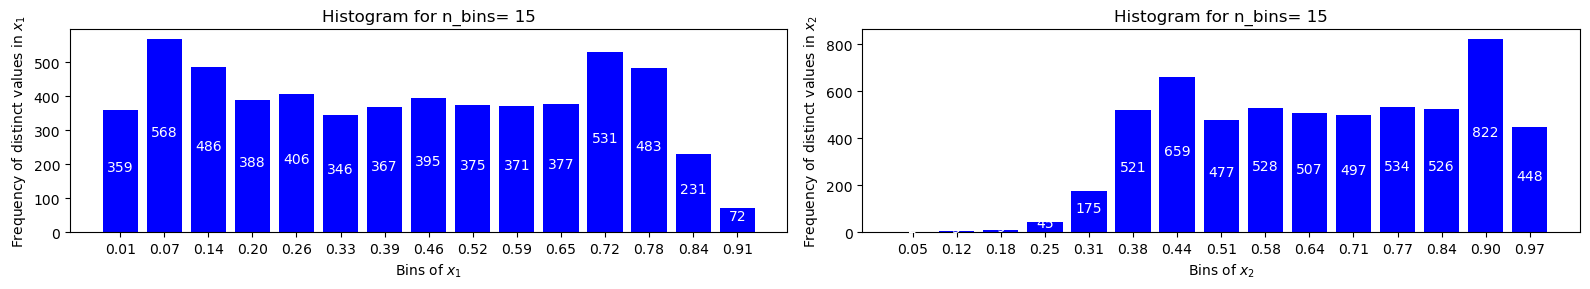

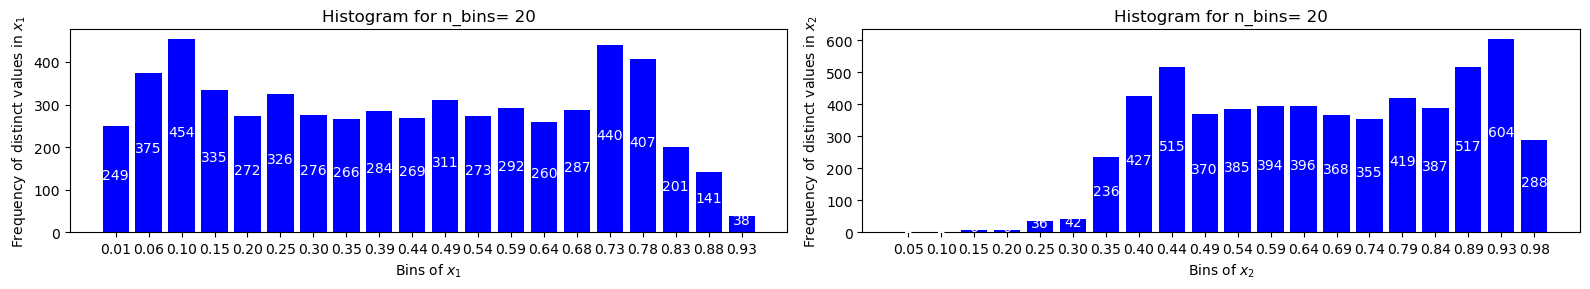

In [295]:
x_hist_eia= []
y_hist_eia= []
y_part_eia= []
x_part_eia= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_eia.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_eia.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_eia.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_eia.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../EIA/solns_runs/Ex8/'+'ex8_eia_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and  KS-Test

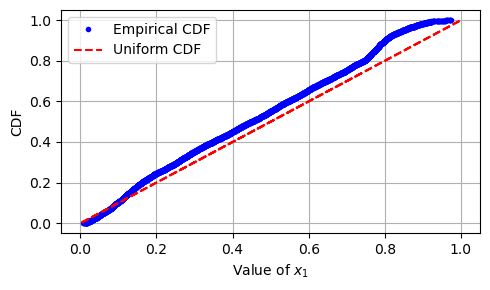

K-S Statistic: 0.10679089508736239
P-Value: 1.2880688679985377e-57
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [296]:
# KS Test on x: 
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xeia)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xeia)
ecdf_eia_x = ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_x.x, ecdf_eia_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../EIA/solns_runs/Ex8/ks_ex8_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xeia, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.") 

In [297]:
ks_statistic,p_value

(0.10679089508736239, 1.2880688679985377e-57)

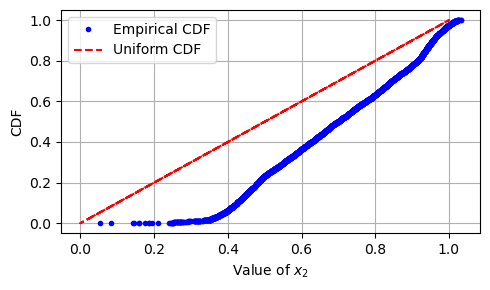

K-S Statistic: 0.3394024139618472
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [298]:
# KS Test on y: 
# Number of samples
a,b= 0.0, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(yeia)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(yeia)
ecdf_eia_y = ECDF(yeia) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_y.x, ecdf_eia_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../EIA/solns_runs/Ex8/ks_ex8_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(yeia, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# SGD (one run with 100 points)

In [299]:
main_path = "../SGD/solns_runs/Ex8/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../SGD/solns_runs/Ex8/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../SGD/solns_runs/Ex8/N_100/',
 '../SGD/solns_runs/Ex8/N_200/',
 '../SGD/solns_runs/Ex8/N_300/',
 '../SGD/solns_runs/Ex8/N_400/',
 '../SGD/solns_runs/Ex8/N_500/',
 '../SGD/solns_runs/Ex8/N_600/',
 '../SGD/solns_runs/Ex8/N_700/',
 '../SGD/solns_runs/Ex8/N_800/',
 '../SGD/solns_runs/Ex8/N_900/',
 '../SGD/solns_runs/Ex8/N_1000/',
 '../SGD/solns_runs/Ex8/N_1100/',
 '../SGD/solns_runs/Ex8/N_1200/',
 '../SGD/solns_runs/Ex8/N_1300/',
 '../SGD/solns_runs/Ex8/N_1400/',
 '../SGD/solns_runs/Ex8/N_1500/']

In [300]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')[:,:-1]
            #mask= solns[:,-1]<=0.01
            #solns= solns[mask][:,:-1]
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        point1 = (0, 1)
        point2 = (2/3, 2/3)

        # Number of points you want to generate

        # Generate points along the line segment
        points0 = [(point1[0] + t * (point2[0] - point1[0]), point1[1] + t * (point2[1] - point1[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3))]
        # points0= np.array(points0)


        # Define the three points
        point1 = (0, 1)
        point2 = (2/3, 2/3)
        point3 = (1, 0)

        # Number of points you want to generate on each segment


        # Generate points along the first segment
        points1 = [(point1[0] + t * (point2[0] - point1[0]), point1[1] + t * (point2[1] - point1[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3))]

        # Generate points along the second segment
        points2 = [(point2[0] + t * (point3[0] - point2[0]), point2[1] + t * (point3[1] - point2[1])) for t in np.linspace(0, 1, int(len(distinct_points)/3)+1)]

        # Combine the points from both segments
        points = points0+points1 + points2
        points= np.array(points)

        

        print(len(distinct_points),len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../GSM/solns_runs/Ex8/plot_ex8.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

524 1000
1134 2000
1820 3000
2639 4000
3454 5000
4361 6000
5302 7000
6279 8000
7177 9000
8090 10000
9103 11000
9974 12000
11012 13000
12016 14000
13044 15000


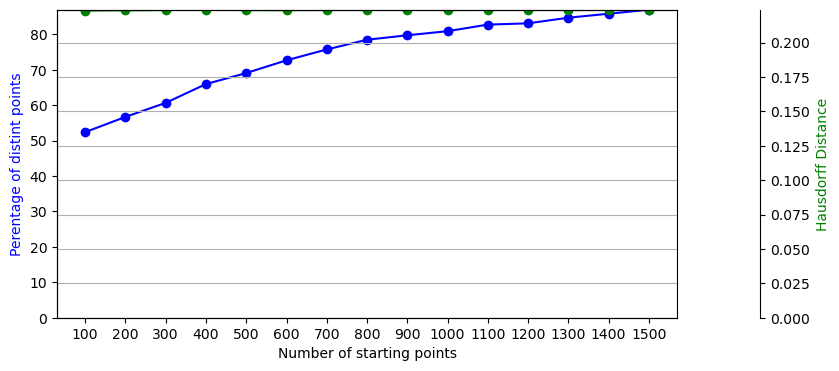

In [301]:
pdpsgd, hdsgd= get_values(folders)

In [302]:
for (p,h) in zip(pdpsgd,hdsgd):
    print(p, " * ", h)

52.400000000000006  *  0.22335189366496164
56.699999999999996  *  0.22354024379374493
60.66666666666667  *  0.22372269924788804
65.975  *  0.22399266005890422
69.08  *  0.22366910772187917
72.68333333333334  *  0.2236414101265482
75.74285714285715  *  0.22376330179521198
78.4875  *  0.2237717823887261
79.74444444444444  *  0.22388642206110673
80.9  *  0.2237290867348647
82.75454545454546  *  0.2238022043315665
83.11666666666667  *  0.22392578909079375
84.70769230769231  *  0.22373590365275353
85.82857142857144  *  0.22378575422387953
86.96000000000001  *  0.2238559981507652


## Histograms

In [303]:
nubmer_points_list[np.argmax(pdpsgd)]

1500

In [304]:
n_points= nubmer_points_list[np.argmax(pdpsgd)]
# Best
directory_path = "../SGD/solns_runs/Ex8/N_{}".format(n_points)
all_solnssgd= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')[:,:-1]
    #mask= solns[:,-1]<0.01
    #solns= solns[mask]
#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    
    all_solnssgd.extend(solns.tolist())


all_solnssgd= np.array(all_solnssgd)

num, all_solnssgd = count_repeated_points(all_solnssgd)
all_solnssgd= np.array(all_solnssgd)
all_solnssgd

array([[0.70191898, 0.29783021],
       [0.50010557, 0.5003157 ],
       [0.25541121, 0.74438451],
       ...,
       [0.89208089, 0.10749202],
       [0.56004092, 0.43980515],
       [0.24215677, 0.7579401 ]])

In [305]:
all_solnssgd.shape

(13044, 2)

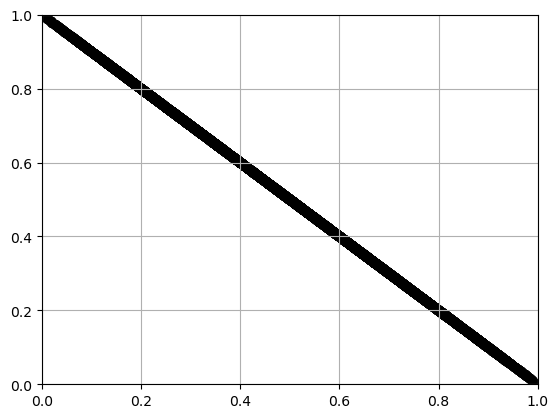

In [306]:
plt.scatter(all_solnssgd[:,0], all_solnssgd[:,1], c= 'black')
plt.xlim([0,1.0])
plt.ylim([0,1.0])
plt.grid(True)
plt.show()

In [307]:
len(all_solnssgd)

13044

In [308]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnssgd.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= solns[:,1]
y_min = np.min(y)
y_max = np.max(y)
# y

xsgd= x.copy()
ysgd= y.copy()

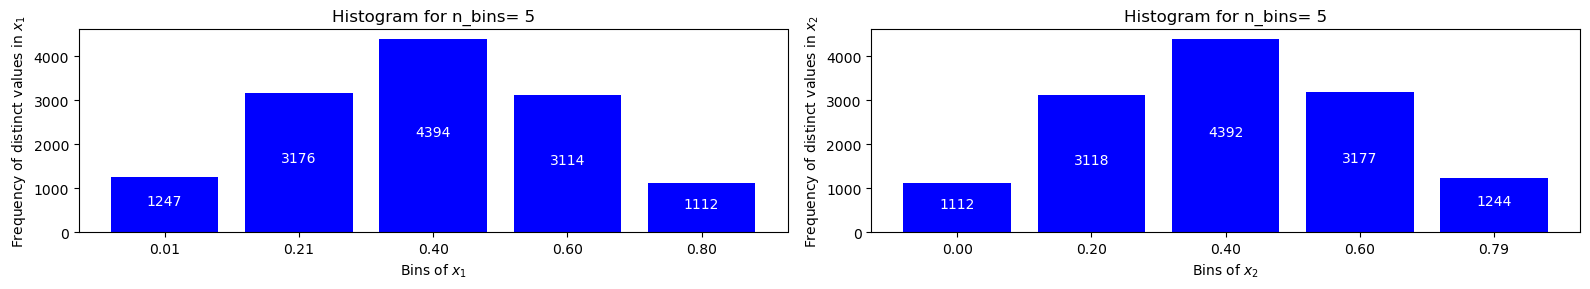

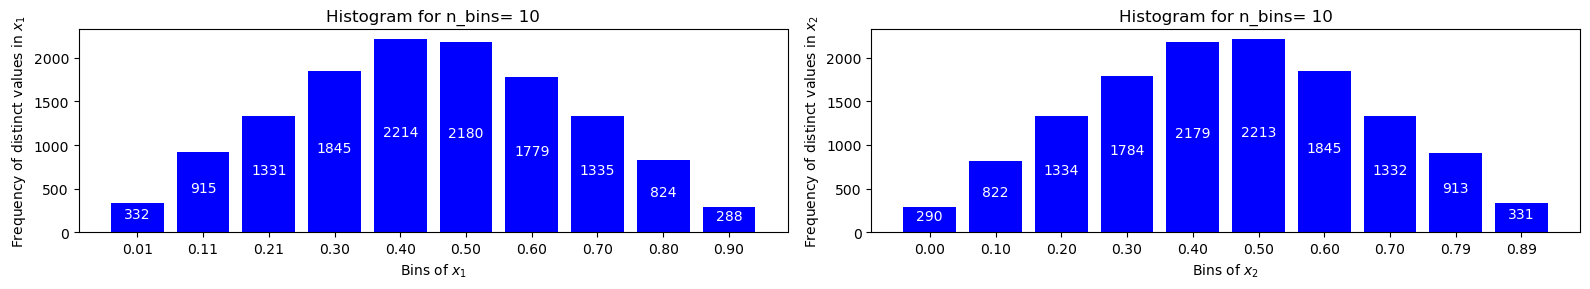

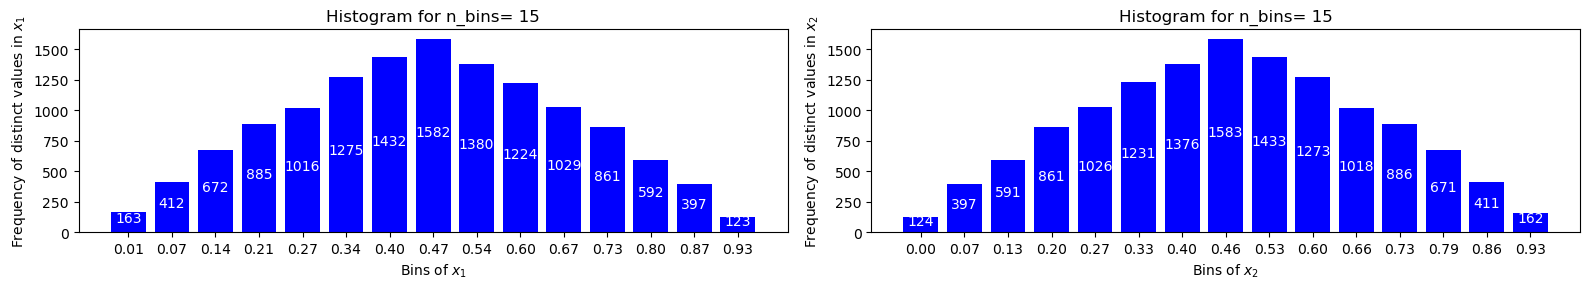

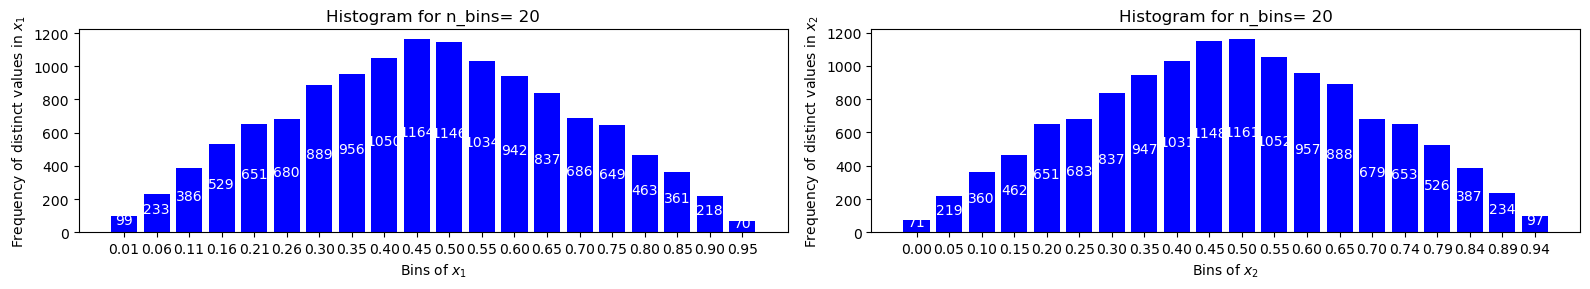

In [309]:
x_hist_sgd= []
y_hist_sgd= []
y_part_sgd= []
x_part_sgd= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_sgd.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_sgd.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_sgd.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_sgd.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../SGD/solns_runs/Ex8/'+'ex8_sgd_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF and KS-Test

## K-S Test

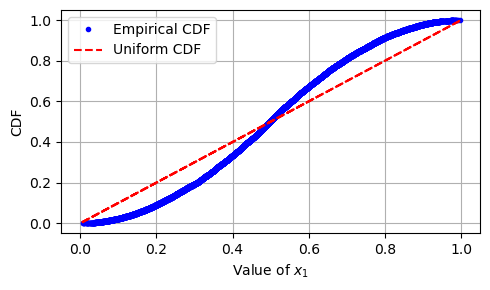

K-S Statistic: 0.11596774032948409
P-Value: 2.762204116138186e-153
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [310]:
# KS Test on x: 
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xsgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xsgd)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xsgd)
ecdf_sgd_x = ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_x.x, ecdf_sgd_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('Value of $x_1$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../SGD/solns_runs/Ex8/ks_ex8_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xsgd, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.") 

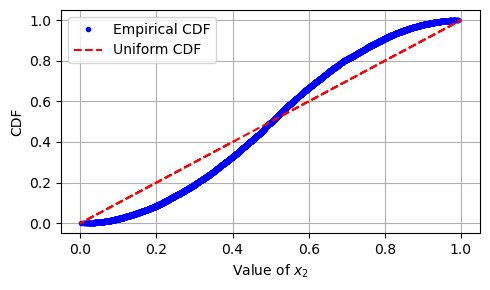

K-S Statistic: 0.11602721036089918
P-Value: 1.9230059927501411e-153
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [311]:
# KS Test on y: 
# Number of samples
a,b= 0.0, 1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(ysgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ysgd)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ysgd)
ecdf_sgd_y = ECDF(ysgd) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_y.x, ecdf_sgd_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('Value of $x_2$')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../SGD/solns_runs/Ex8/ks_ex8_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ysgd, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# KS-Overall

In [312]:
def KS_test(sample, a, b, alpha=0.05):
    ecdf_sgd_x = ECDF(sample)
    x1 = ecdf_sgd_x.x       # First coordinate
    # ecdf_sgd_y = ECDF(ysgd)
    # x2 = ecdf_sgd_y.x   # Second coordinate
    # print("Algorithm ", name)
    ks_statistic, p_value = stats.kstest(sample, "uniform", args=(a, b-a))
    print(f"K-S Statistic: {ks_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")
    if p_value > alpha:
        print(f"Result: Fail to reject H0 → Sample follows Uniform({a},{b})\n")
    else:
        print(f"Result: Reject H0 → Sample does NOT follow Uniform({a},{b})\n")

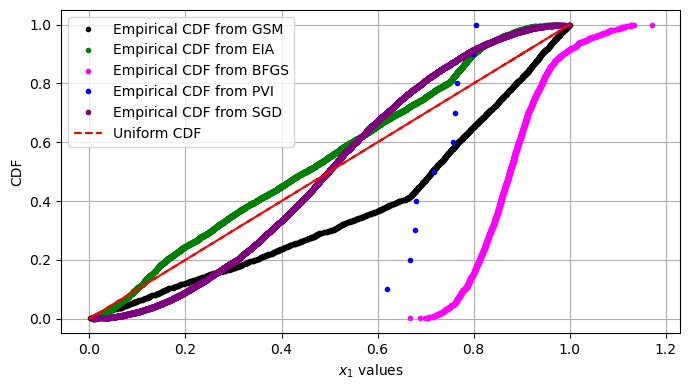

GSM
K-S Statistic: 0.2537
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.0017154156905472284,0.9998505512227859)

*********
EIA
K-S Statistic: 0.0856
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.00704524534886458,0.9734492868393226)

*********
BFGS
K-S Statistic: 0.2773
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.6666666666666666,1.1713113722015285)

*********
PVI
K-S Statistic: 0.2401
P-Value: 0.5352
Result: Fail to reject H0 → Sample follows Uniform(0.6195582179988754,0.8055565679810754)

*********
SGD
K-S Statistic: 0.1165
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.007519202885627898,0.9984865390458153)

*********


In [313]:
# KS Test on x: 
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
#uniform_samples= np.hstack((uniform_samples,5))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
sorted_samples = np.sort(x)
ecdfgsm= ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('$x_1$ values')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex8/all_ks_ex8_x1.png')
plt.show()

print("GSM")
KS_test(xgsm, min(xgsm), max(xgsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(xeia, min(xeia), max(xeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(xbfgs, min(xbfgs), max(xbfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(xpvi, min(xpvi), max(xpvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(xsgd, min(xsgd), max(xsgd), alpha=0.05)
print("*********")

In [314]:
uniform_samples

array([0.92589332, 0.49626992, 0.54933277, ..., 0.96209833, 0.87932995,
       0.86482457])

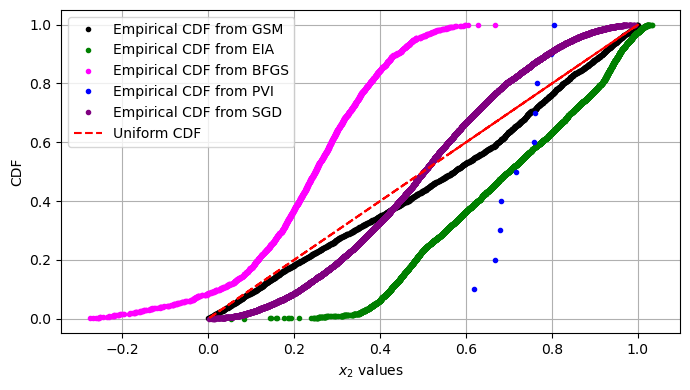

GSM
K-S Statistic: 0.0812
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.0002988975544286898,0.9991422921547264)

*********
EIA
K-S Statistic: 0.2935
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.05310057254623146,1.032513197841201)

*********
BFGS
K-S Statistic: 0.2349
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(-0.2763361483867224,0.6666666666666666)

*********
PVI
K-S Statistic: 0.2262
P-Value: 0.6092
Result: Fail to reject H0 → Sample follows Uniform(0.3888798284123775,0.6902169313500439)

*********
SGD
K-S Statistic: 0.1166
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(0.0013783725284243766,0.9926001542816256)

*********


In [315]:
# KS Test on y: 
# Number of samples
a,b= 0.0,1.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
# uniform_samples= np.hstack((uniform_samples,9))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
sorted_samples = np.sort(y)
ecdfgsm= ECDF(ygsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(yeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(ybfgs) #np.arange(1, n_samples+1) / n_samples
# ecdfpvi= ECDF(ypvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(ysgd)

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('$x_2$ values')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex8/all_ks_ex8_x2.png')
plt.show()


    
print("GSM")
KS_test(ygsm, min(ygsm), max(ygsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(yeia, min(yeia), max(yeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(ybfgs, min(ybfgs), max(ybfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(ypvi, min(ypvi), max(ypvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(ysgd, min(ysgd), max(ysgd), alpha=0.05)
print("*********")

In [316]:
nubmer_points_list= [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500]

In [317]:
len(pdpgsm),len(pdpeia),len(pdpbfgs),len(pdpsgd),len(pdppvi)
nubmer_points_list

[100,
 200,
 300,
 400,
 500,
 600,
 700,
 800,
 900,
 1000,
 1100,
 1200,
 1300,
 1400,
 1500]

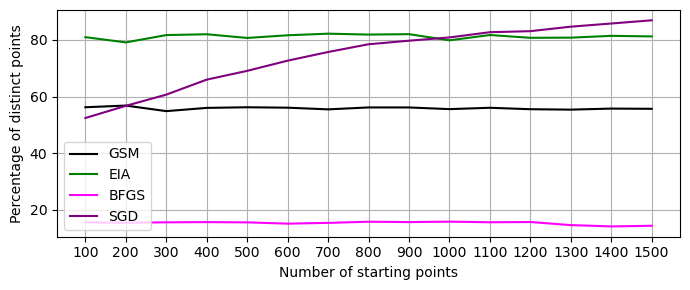

In [318]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, pdpgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, pdpeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, pdpbfgs, label='BFGS',c= 'magenta')

# plt.plot(nubmer_points_list, pdppvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, pdpsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Percentage of distinct points')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex8/ex8_npoints_pdp.png')
plt.show()

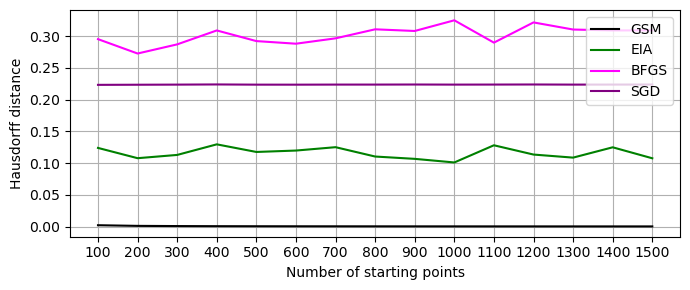

In [319]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, hdgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, hdeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, hdbfgs, label='BFGS',c= 'magenta')

# plt.plot(nubmer_points_list, hdgpvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, hdsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Hausdorff distance')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex8/ex8_npoints_hd.png')
plt.show()

In [320]:
hdsgd

[0.22335189366496164,
 0.22354024379374493,
 0.22372269924788804,
 0.22399266005890422,
 0.22366910772187917,
 0.2236414101265482,
 0.22376330179521198,
 0.2237717823887261,
 0.22388642206110673,
 0.2237290867348647,
 0.2238022043315665,
 0.22392578909079375,
 0.22373590365275353,
 0.22378575422387953,
 0.2238559981507652]

# Histograms

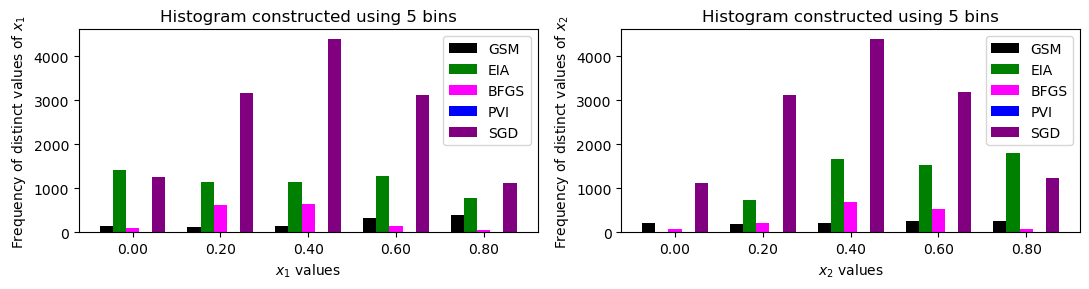

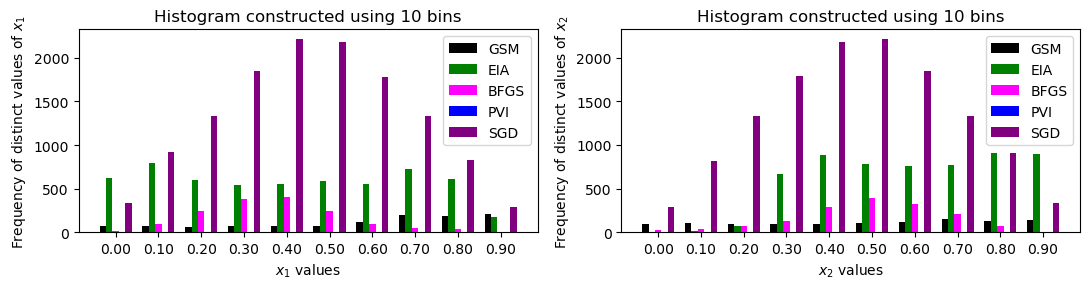

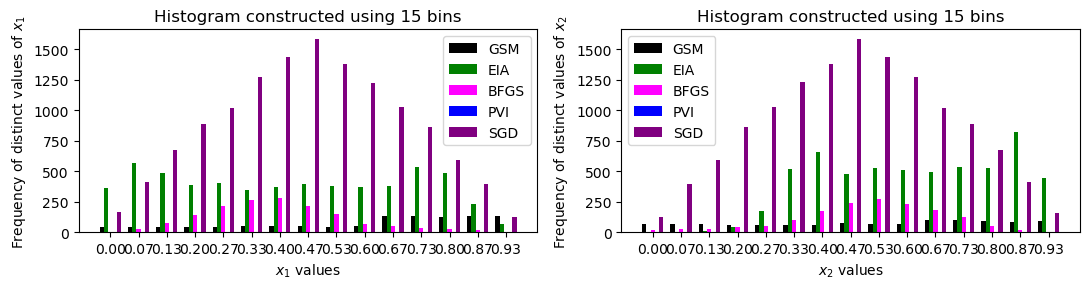

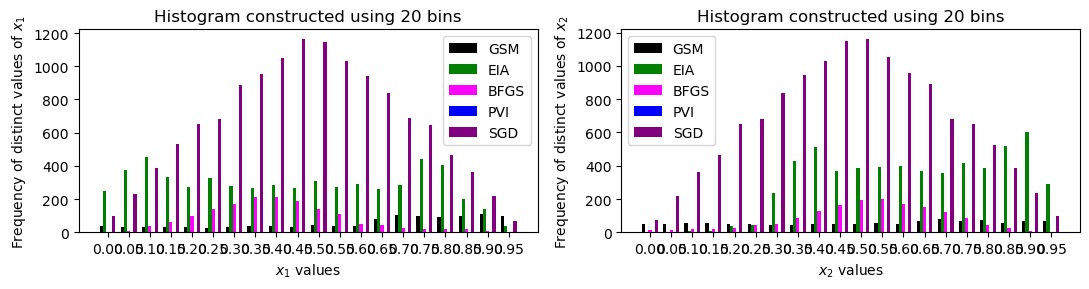

In [321]:
import matplotlib.pyplot as plt
import numpy as np

for n_bins in range(len(bins_list)):
    plt.figure(figsize=(11, 3))  # Increase the figure height for better readability
    
    width = 0.15  # Width of the bars
    
    # First subplot for x_hist_gsm and x_hist_eia
    plt.subplot(1, 2, 1)
    
    x = np.arange(len(x_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(x - 2*width, list(x_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(x - width, list(x_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(x, list(x_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(x + width, list(x_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(x + 2*width, list(x_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')
    
    # Customize plot
    plt.xticks(x, ["{:.2f}".format(b) for b in x_part_gsm[n_bins][:-1]])
    plt.xlabel('$x_1$ values')
    plt.ylabel('Frequency of distinct values of $x_1$')
    plt.title('Histogram constructed using {} bins'.format(len(x_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    #plt.title('Histogram for n_bins= {}'.format(len(x_hist_gsm[n_bins])))
    # plt.legend(loc='upper right')
#     plt.grid(True)
    
    # Second subplot for y_hist_gsm and y_hist_eia
    plt.subplot(1, 2, 2)
    
    y = np.arange(len(y_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(y - 2*width, list(y_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(y - width, list(y_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(y, list(y_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(y + width, list(y_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(y + 2*width, list(y_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')

    # Customize plot
    plt.xticks(y, ["{:.2f}".format(b) for b in y_part_gsm[n_bins][:-1]])
    plt.xlabel('$x_2$ values')
    plt.ylabel('Frequency of distinct values of $x_2$')
    plt.title('Histogram constructed using {} bins'.format(len(y_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    #plt.title('Histogram for n_bins= {}'.format(len(y_hist_gsm[n_bins])))
    # plt.legend(loc='upper right')
#     plt.grid(True)
    
    plt.tight_layout()
    # Uncomment the next line to save the plot
    plt.savefig('../KS-Plots/Ex8/'+'ex8_hist_bin'+str(bins_list[n_bins])+'.png')
    plt.show()


In [322]:
Ex7Sols= {
        "EIA":
                {
                    "hd": None, "pdp": None, "solutions": None
                },

     "SGD":{
        "hd":None, "pdp": None, "solutions":None
    },

     "GSM":{
        "hd":None, "pdp": None, "solutions":None
    },

     "PVI":{
        "hd":None, "pdp": None, "solutions":None
    },

     "BFGS":{
        "hd":None, "pdp": None, "solutions":None
    }



}

Algorithms= ["EIA", "SGD", "GSM", "PVI", "BFGS"]

HDResults= [hdeia, hdsgd, hdgsm, hdgpvi, hdbfgs]
PDPResults= [pdpeia, pdpsgd, pdpgsm, pdppvi, pdpbfgs]
# dataSol= [data_eia, data_sgd, data_gsm, data_pvi, data_bfgs]

for (idx, algo) in enumerate(Algorithms):

    Ex7Sols[algo]["hd"]= HDResults[idx]
    Ex7Sols[algo]["pdp"]= PDPResults[idx]
    # Ex4Sols[algo]["solutions"]= dataSol[idx]


import json

def convert_ndarray(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

with open("Ex7Sols.json", "w", encoding="utf-8") as f:
    json.dump(Ex7Sols, f, indent=4, default=convert_ndarray)


import json

with open("Ex7Sols.json", "r", encoding="utf-8") as f:
    Ex7Sols = json.load(f)

